In [1]:
import sys
from pathlib import Path

import numpy as np
from skimage.feature import hog

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists() and (p / "data").exists()),
    Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.regularization import regularization_terms
from src.utils.bias_variance_analysis import complexity_curve, learning_curve, summarize_bias_variance


In [2]:
def load_data(path, isImage):
    with open(path, 'rb') as f:
        data = f.read()

    magic = int.from_bytes(data[0:4], 'big')
    num_images = int.from_bytes(data[4:8], 'big')
    rows = int.from_bytes(data[8:12], 'big')
    cols = int.from_bytes(data[12:16], 'big')

    if isImage:
        offset = 16  # images have 16-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        arr = arr.reshape(num_images, rows, cols)
    else:
        offset = 8  # labels have 8-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)

    return arr


def load_mnist():
    mnist_dir = PROJECT_ROOT / "data" / "mnist_dataset"
    x_train = load_data(mnist_dir / "train-images-idx3-ubyte", True)
    y_train = load_data(mnist_dir / "train-labels-idx1-ubyte", False)
    x_test = load_data(mnist_dir / "t10k-images-idx3-ubyte", True)
    y_test = load_data(mnist_dir / "t10k-labels-idx1-ubyte", False)
    return x_train, y_train, x_test, y_test


In [3]:
x_train, y_train, x_test, y_test = load_mnist()

In [4]:
def data_preprocessing(x_train_split, x_val_split):
    return x_train_split/255.0, x_val_split/255.0

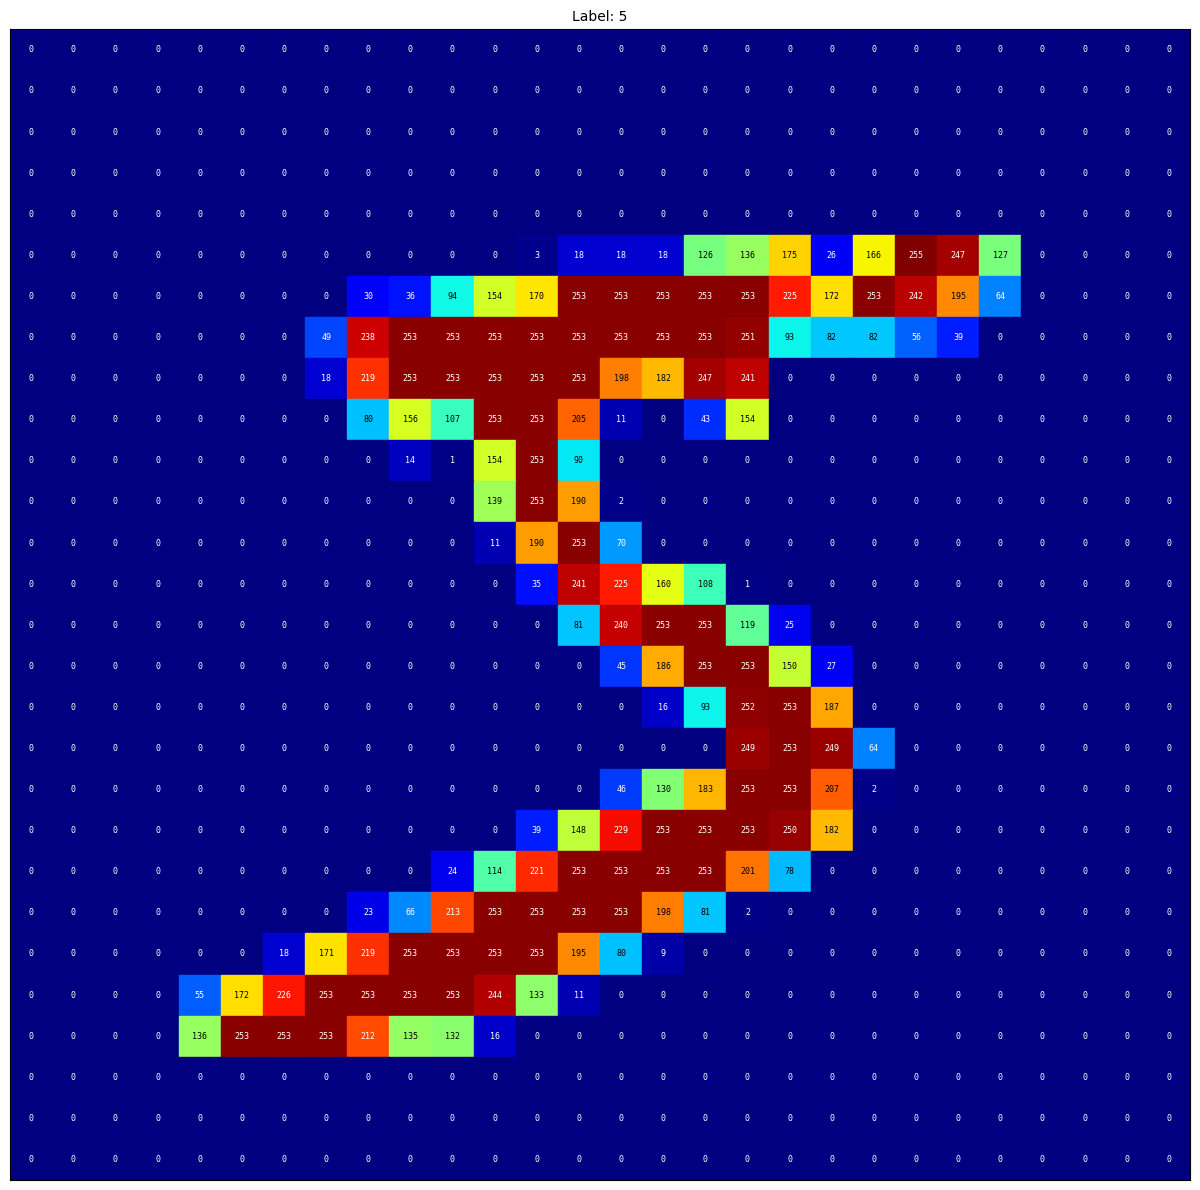

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

num_images = 1
cols = 3
rows = math.ceil(num_images / cols)
cmap = plt.cm.jet  # or: plt.cm.hot, plt.cm.viridis, etc.

fig, axes = plt.subplots(rows, cols, figsize=(cols * 12, rows * 12))
axes = axes.flatten()

for i in range(num_images):
    ax = axes[i]
    img = x_train[i]  # shape: (28, 28), values 0–255

    # Normalize to [0, 1] for colormap
    norm_img = img / 255.0

    for row in range(28):
        for col in range(28):
            val = img[row, col]
            t = val / 255.0
            color = cmap(t)
            # Pick white or black text based on background luminance
            lum = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
            text_color = 'black' if lum > 0.5 else 'white'
            ax.text(col, row, str(val),
                    ha='center', va='center',
                    fontsize=6, color=text_color,
                    fontfamily='monospace')
            ax.add_patch(plt.Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                color=color, zorder=0
            ))

    ax.set_xlim(-0.5, 27.5)
    ax.set_ylim(27.5, -0.5)  # flip y so row 0 is at top
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Label: {y_train[i]}", fontsize=10)

# Hide unused subplots
for j in range(num_images, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("pixel_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

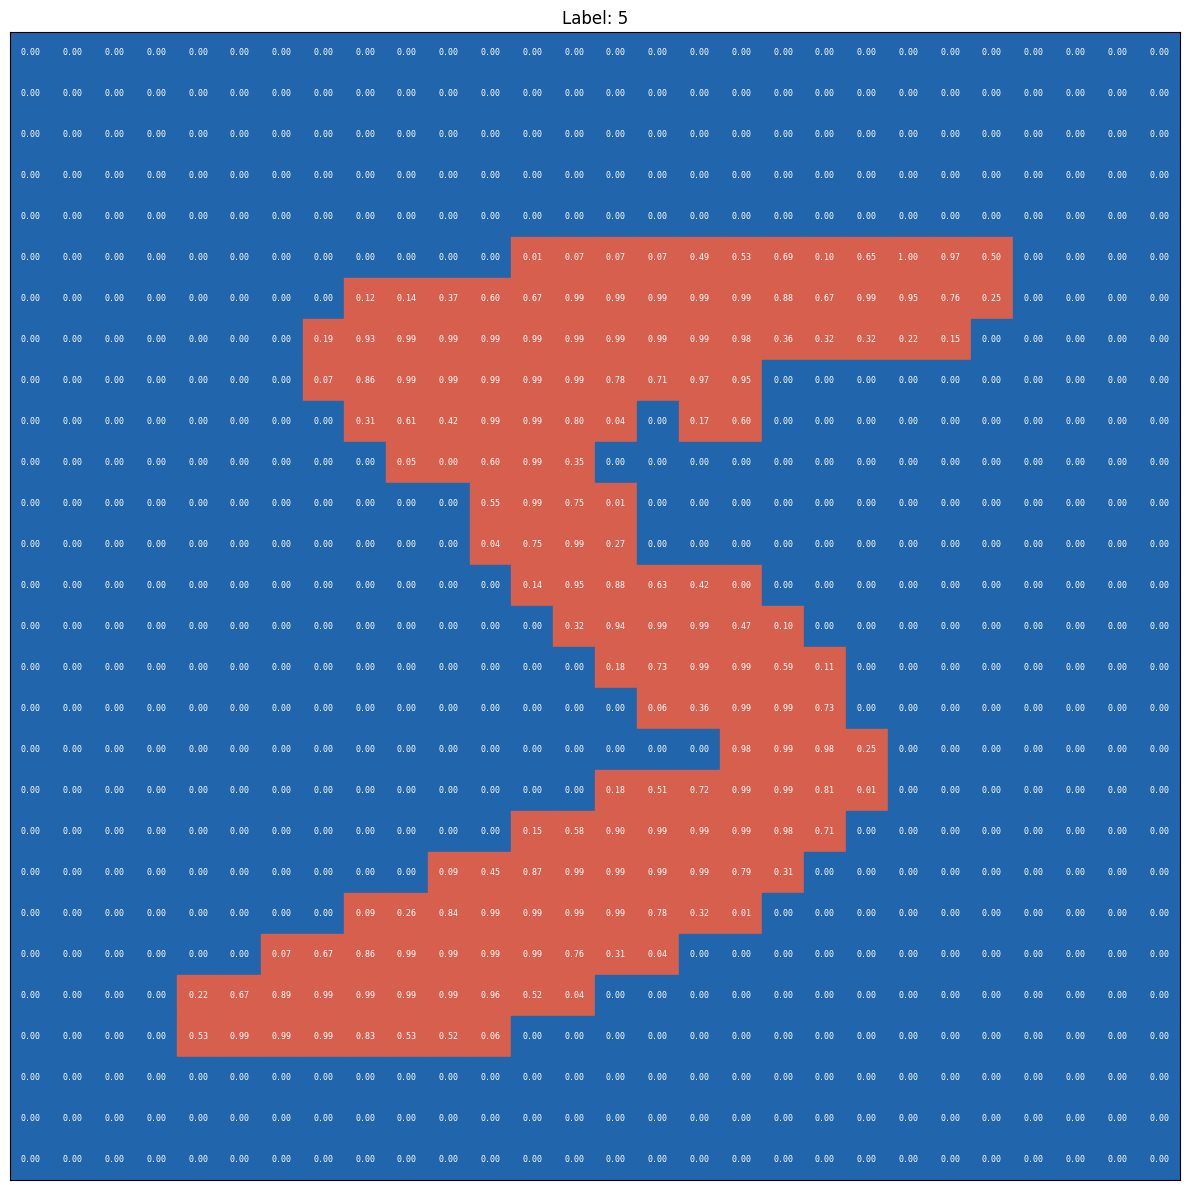

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import math

num_images = 1
cols = 1
rows = math.ceil(num_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = np.array([axes]).flatten()

for i in range(num_images):
    ax = axes[i]
    img = x_train[i] / 255.0  # shape: (28, 28), values 0.0–1.0

    for row in range(28):
        for col in range(28):
            val = img[row, col]
            is_zero = val == 0.0
            bg_color = '#2166ac' if is_zero else '#d6604d'  # blue : red
            text_color = 'white'
            ax.add_patch(plt.Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                color=bg_color, zorder=0
            ))
            ax.text(col, row, f"{val:.2f}",
                    ha='center', va='center',
                    fontsize=6, color=text_color,
                    fontfamily='monospace')

    ax.set_xlim(-0.5, 27.5)
    ax.set_ylim(27.5, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Label: {y_train[i]}", fontsize=12)

plt.tight_layout()
plt.savefig("pixel_heatmap_normalized.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
def data_preprocessing_hog(x_train, x_val, n_components=0.95):
    x_train_hog = np.array([hog(img, orientations=9, pixels_per_cell=(8, 8), 
                                cells_per_block=(2, 2)) for img in x_train])

    x_val_hog = np.array([hog(img, orientations=9, pixels_per_cell=(8, 8), 
                              cells_per_block=(2, 2)) for img in x_val])
    
    # 2. Manual L2 Normalization
    x_train_norm = x_train_hog / (np.linalg.norm(x_train_hog, axis=1, keepdims=True) + 1e-8)
    x_val_norm = x_val_hog / (np.linalg.norm(x_val_hog, axis=1, keepdims=True) + 1e-8)

    
    return x_train_norm, x_val_norm

In [8]:
def data_distribution(x_train, y_train, model_digit):
    x_train_raw, x_val_raw = x_train[:50000], x_train[50000:]
    y_train_raw, y_val_raw = y_train[:50000], y_train[50000:]

    return x_train_raw, y_train_raw, x_val_raw, y_val_raw

In [9]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def prepare_logistic_features(x_train_split, x_val_split):
    x_train_features, x_val_features = data_preprocessing_hog(x_train_split, x_val_split)

    x_train_flat = x_train_features.reshape(x_train_features.shape[0], -1)
    x_train_bias = np.hstack([x_train_flat, np.ones((x_train_features.shape[0], 1))])

    x_val_flat = x_val_features.reshape(x_val_features.shape[0], -1)
    x_val_bias = np.hstack([x_val_flat, np.ones((x_val_features.shape[0], 1))])

    return x_train_bias, x_val_bias


def binary_cross_entropy(y_true, y_hat):
    y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_hat) + (1 - y_true) * np.log(1 - y_hat))


def train_logistic_weights(
    x_train_bias,
    y_train_binary,
    x_val_bias,
    y_val_binary,
    batch_size=32,
    learning_rate=0.01,
    validation_patience=5,
    epsilon=1e-4,
    max_epochs=100,
    penalty=None,
    lambda_=0.0,
    random_state=42,
    train_eval_limit=2000,
    verbose=True,
):
    rng = np.random.default_rng(random_state)
    weights = rng.uniform(low=-0.01, high=0.01, size=(x_train_bias.shape[1], 1))

    best_v_loss = float('inf')
    best_weights = weights.copy()
    counter = 0
    history = []

    n_samples = x_train_bias.shape[0]
    n_pos = np.sum(y_train_binary == 1)
    n_neg = n_samples - n_pos

    if n_pos == 0 or n_neg == 0:
        raise ValueError("Training data must contain both positive and negative samples.")

    # Class-balanced sample weights keep the minority digit from being ignored.
    w_pos = n_samples / (2 * n_pos)
    w_neg = n_samples / (2 * n_neg)

    eval_size = min(train_eval_limit, n_samples)
    eval_indices = rng.choice(n_samples, size=eval_size, replace=False)
    x_train_eval = x_train_bias[eval_indices]
    y_train_eval = y_train_binary[eval_indices]

    for epoch in range(max_epochs):
        indices = rng.permutation(n_samples)
        x_shuffled = x_train_bias[indices]
        y_shuffled = y_train_binary[indices]

        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)

            xi_batch = x_shuffled[start:end]
            yi_batch = y_shuffled[start:end]

            y_hat = sigmoid(np.dot(xi_batch, weights))
            sample_weights = yi_batch * w_pos + (1 - yi_batch) * w_neg
            error = (y_hat - yi_batch) * sample_weights

            data_gradient = np.dot(xi_batch.T, error) / xi_batch.shape[0]
            _, reg_gradient = regularization_terms(
                weights,
                penalty=penalty,
                lambda_=lambda_,
                regularize_bias=False,
            )

            weights -= learning_rate * (data_gradient + reg_gradient)

        train_hat = sigmoid(np.dot(x_train_eval, weights))
        val_hat = sigmoid(np.dot(x_val_bias, weights))
        reg_loss, _ = regularization_terms(
            weights,
            penalty=penalty,
            lambda_=lambda_,
            regularize_bias=False,
        )

        train_loss = binary_cross_entropy(y_train_eval, train_hat) + reg_loss
        val_loss = binary_cross_entropy(y_val_binary, val_hat) + reg_loss

        train_pred = (train_hat >= 0.5).astype(float)
        val_pred = (val_hat >= 0.5).astype(float)
        train_accuracy = np.mean(train_pred == y_train_eval)
        val_accuracy = np.mean(val_pred == y_val_binary)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "penalty": penalty,
            "lambda_": lambda_,
        })

        if val_loss < best_v_loss - epsilon:
            best_v_loss = val_loss
            best_weights = weights.copy()
            counter = 0
        else:
            counter += 1

        if verbose:
            print(f"Epoch: {epoch}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Val Acc: {val_accuracy:.4f}")

        if counter >= validation_patience:
            if verbose:
                print("Early stopping triggered.")
            break

    return best_weights, history


def logistic_regression(
    x_train,
    y_train,
    model_digit,
    batch_size=32,
    learning_rate=0.01,
    validation_patience=5,
    epsilon=1e-4,
    max_epochs=100,
    penalty=None,
    lambda_=0.0,
    random_state=42,
    train_eval_limit=2000,
    return_history=False,
    verbose=True,
):
    x_train_split, y_train_split, x_val, y_val = data_distribution(x_train, y_train, model_digit)
    x_train_bias, x_val_bias = prepare_logistic_features(x_train_split, x_val)

    y_train_binary = (y_train_split == model_digit).astype(float).reshape(-1, 1)
    y_val_binary = (y_val == model_digit).astype(float).reshape(-1, 1)

    weights, history = train_logistic_weights(
        x_train_bias=x_train_bias,
        y_train_binary=y_train_binary,
        x_val_bias=x_val_bias,
        y_val_binary=y_val_binary,
        batch_size=batch_size,
        learning_rate=learning_rate,
        validation_patience=validation_patience,
        epsilon=epsilon,
        max_epochs=max_epochs,
        penalty=penalty,
        lambda_=lambda_,
        random_state=random_state,
        train_eval_limit=train_eval_limit,
        verbose=verbose,
    )

    if return_history:
        return weights, history
    return weights


In [10]:
MODEL_DIGIT = 5

weights, training_history = logistic_regression(
    x_train,
    y_train,
    MODEL_DIGIT,
    batch_size=16,
    learning_rate=0.05,
    validation_patience=20,
    epsilon=1e-10,
    max_epochs=100,
    penalty="l2",
    lambda_=0.001,
    random_state=42,
    return_history=True,
)


Epoch: 0, Train Loss: 0.372091, Val Loss: 0.355743, Val Acc: 0.9052
Epoch: 1, Train Loss: 0.319310, Val Loss: 0.302461, Val Acc: 0.9239
Epoch: 2, Train Loss: 0.289349, Val Loss: 0.273495, Val Acc: 0.9398
Epoch: 3, Train Loss: 0.286596, Val Loss: 0.270742, Val Acc: 0.9414
Epoch: 4, Train Loss: 0.276656, Val Loss: 0.261400, Val Acc: 0.9475
Epoch: 5, Train Loss: 0.280962, Val Loss: 0.265471, Val Acc: 0.9463
Epoch: 6, Train Loss: 0.268198, Val Loss: 0.253587, Val Acc: 0.9539
Epoch: 7, Train Loss: 0.279457, Val Loss: 0.264179, Val Acc: 0.9480
Epoch: 8, Train Loss: 0.283738, Val Loss: 0.268183, Val Acc: 0.9469
Epoch: 9, Train Loss: 0.264956, Val Loss: 0.250652, Val Acc: 0.9566
Epoch: 10, Train Loss: 0.284429, Val Loss: 0.268909, Val Acc: 0.9471
Epoch: 11, Train Loss: 0.270003, Val Loss: 0.255392, Val Acc: 0.9542
Epoch: 12, Train Loss: 0.284225, Val Loss: 0.268734, Val Acc: 0.9471
Epoch: 13, Train Loss: 0.282753, Val Loss: 0.267345, Val Acc: 0.9478
Epoch: 14, Train Loss: 0.279464, Val Loss: 0

Results for digit 5 (threshold=0.5):
  Accuracy:  95.46%
  Precision: 0.6714
  Recall:    0.9619
  F1 Score:  0.7908

Confusion Matrix:
[[8688  420]
 [  34  858]]


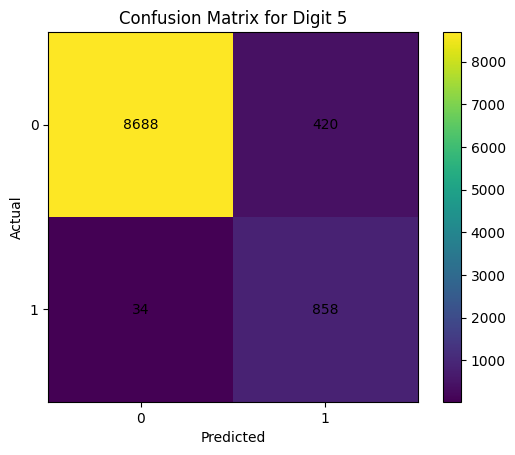

In [11]:
import matplotlib.pyplot as plt


def predict(x_test, y_test, model_digit, w, threshold=0.5):
    x_test_hog, _ = data_preprocessing_hog(x_test, x_test)

    x_test_flat = x_test_hog.reshape(x_test_hog.shape[0], -1)
    x_test_bias = np.hstack([x_test_flat, np.ones((x_test_hog.shape[0], 1))])

    y_hat = sigmoid(np.dot(x_test_bias, w))
    y_true = (y_test == model_digit).astype(float).reshape(-1, 1)
    y_pred = (y_hat >= threshold).astype(float)

    correct = np.sum(y_pred == y_true)
    accuracy = correct / len(y_true) * 100

    true_positives = np.sum((y_pred == 1) & (y_true == 1))
    false_positives = np.sum((y_pred == 1) & (y_true == 0))
    false_negatives = np.sum((y_pred == 0) & (y_true == 1))
    true_negatives = np.sum((y_pred == 0) & (y_true == 0))

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Results for digit {model_digit} (threshold={threshold}):")
    print(f"  Accuracy:  {accuracy:.2f}%")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

    cm = np.array([[true_negatives, false_positives],
                   [false_negatives, true_positives]])
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix for Digit {model_digit}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.xticks([0, 1], ['0', '1'])
    plt.yticks([0, 1], ['0', '1'])
    plt.colorbar()
    plt.show()

    return {
        "accuracy": accuracy / 100,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }


metrics = predict(x_test, y_test, MODEL_DIGIT, weights, threshold=0.5)


## Regularization and Bias-Variance Analysis

Regularization is now handled by one helper: `regularization_terms(weights, penalty, lambda_)`.
It returns two values: the regularization loss and the regularization gradient.

Inside gradient descent, we only add the regularization gradient to the normal data gradient.


In [12]:
import pandas as pd


class PrecomputedBinaryLogistic:
    def __init__(
        self,
        model_digit,
        batch_size=16,
        learning_rate=0.05,
        validation_patience=5,
        epsilon=1e-5,
        max_epochs=20,
        penalty=None,
        lambda_=0.0,
        random_state=42,
        train_eval_limit=1000,
        verbose=False,
    ):
        self.model_digit = model_digit
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.validation_patience = validation_patience
        self.epsilon = epsilon
        self.max_epochs = max_epochs
        self.penalty = penalty
        self.lambda_ = lambda_
        self.random_state = random_state
        self.train_eval_limit = train_eval_limit
        self.verbose = verbose
        self.weights_ = None
        self.history_ = None

    def fit(self, X_bias, y):
        # X_bias is already HOG + bias. This avoids recomputing HOG in every experiment.
        rng = np.random.default_rng(self.random_state)
        indices = rng.permutation(len(X_bias))
        X_bias = X_bias[indices]
        y = y[indices]

        val_size = max(1, int(0.15 * len(X_bias)))
        x_fit_bias, x_val_bias = X_bias[:-val_size], X_bias[-val_size:]
        y_fit, y_val_local = y[:-val_size], y[-val_size:]

        y_fit_binary = (y_fit == self.model_digit).astype(float).reshape(-1, 1)
        y_val_binary = (y_val_local == self.model_digit).astype(float).reshape(-1, 1)

        self.weights_, self.history_ = train_logistic_weights(
            x_train_bias=x_fit_bias,
            y_train_binary=y_fit_binary,
            x_val_bias=x_val_bias,
            y_val_binary=y_val_binary,
            batch_size=self.batch_size,
            learning_rate=self.learning_rate,
            validation_patience=self.validation_patience,
            epsilon=self.epsilon,
            max_epochs=self.max_epochs,
            penalty=self.penalty,
            lambda_=self.lambda_,
            random_state=self.random_state,
            train_eval_limit=self.train_eval_limit,
            verbose=self.verbose,
        )
        return self

    def predict(self, X_bias):
        probabilities = sigmoid(np.dot(X_bias, self.weights_))
        return (probabilities >= 0.5).astype(int).reshape(-1)


def logistic_true_labels(y):
    return (np.asarray(y) == MODEL_DIGIT).astype(int)


In [13]:
x_train_raw, y_train_raw, x_val_raw, y_val_raw = data_distribution(x_train, y_train, MODEL_DIGIT)
x_train_bias_all, x_val_bias_all = prepare_logistic_features(x_train_raw, x_val_raw)

FAST_ANALYSIS_MAX_EPOCHS = 20

regularization_results = complexity_curve(
    model_factory=lambda penalty, lambda_: PrecomputedBinaryLogistic(
        model_digit=MODEL_DIGIT,
        penalty=penalty,
        lambda_=lambda_,
        max_epochs=FAST_ANALYSIS_MAX_EPOCHS,
        validation_patience=5,
        train_eval_limit=1000,
        verbose=False,
    ),
    param_grid=[
        {"penalty": None, "lambda_": 0.0},
        {"penalty": "l2", "lambda_": 0.0001},
        {"penalty": "l2", "lambda_": 0.001},
        {"penalty": "l1", "lambda_": 0.0001},
    ],
    X_train=x_train_bias_all,
    y_train=y_train_raw,
    X_val=x_val_bias_all,
    y_val=y_val_raw,
    transform_y_fn=logistic_true_labels,
    model_name="logistic_regularization",
)

regularization_results = summarize_bias_variance(
    regularization_results,
    target_score=0.90,
    gap_threshold=0.05,
)
regularization_results.sort_values("val_score", ascending=False)


,model,train_score,val_score,gap,penalty,lambda_,diagnosis
0,logistic_regularization,0.95590,0.9633,-0.00740,None,0.0000,balanced
3,logistic_regularization,0.95540,0.9622,-0.00680,l1,0.0001,balanced
1,logistic_regularization,0.95096,0.9581,-0.00714,l2,0.0001,balanced
2,logistic_regularization,0.94528,0.9516,-0.00632,l2,0.0010,balanced


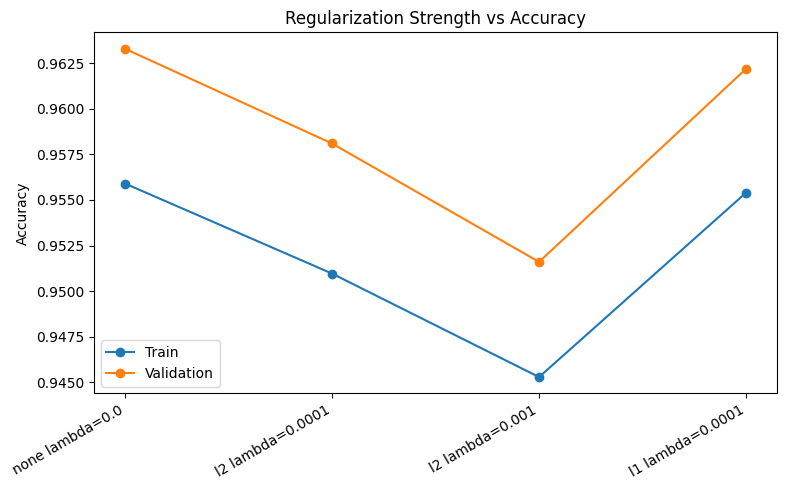

In [14]:
plt.figure(figsize=(8, 5))
labels = regularization_results.apply(
    lambda row: f"{row['penalty'] or 'none'} lambda={row['lambda_']}", axis=1
)
plt.plot(labels, regularization_results["train_score"], marker="o", label="Train")
plt.plot(labels, regularization_results["val_score"], marker="o", label="Validation")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Regularization Strength vs Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
best_row = regularization_results.sort_values("val_score", ascending=False).iloc[0]
print("Best regularization setting:")
print(best_row[["penalty", "lambda_", "train_score", "val_score", "gap", "diagnosis"]])

bias_variance_results = learning_curve(
    model_factory=lambda: PrecomputedBinaryLogistic(
        model_digit=MODEL_DIGIT,
        penalty=best_row["penalty"],
        lambda_=best_row["lambda_"],
        max_epochs=FAST_ANALYSIS_MAX_EPOCHS,
        validation_patience=5,
        train_eval_limit=1000,
        verbose=False,
    ),
    X_train=x_train_bias_all,
    y_train=y_train_raw,
    X_val=x_val_bias_all,
    y_val=y_val_raw,
    train_sizes=[0.1, 0.25, 0.5, 1.0],
    seeds=[0, 1],
    transform_y_fn=logistic_true_labels,
    model_name="logistic_learning_curve",
)

bias_variance_summary = summarize_bias_variance(
    bias_variance_results,
    target_score=0.90,
    gap_threshold=0.05,
)
bias_variance_summary


Best regularization setting:
penalty            None
lambda_             0.0
train_score      0.9559
val_score        0.9633
gap             -0.0074
diagnosis      balanced
Name: 0, dtype: object


,model,train_size,train_size_requested,seed,train_score,val_score,gap,diagnosis
0,logistic_learning_curve,5000,0.10,0,0.93480,0.9411,-0.00630,balanced
1,logistic_learning_curve,5000,0.10,1,0.92900,0.9363,-0.00730,balanced
2,logistic_learning_curve,12500,0.25,0,0.93944,0.9517,-0.01226,balanced
3,logistic_learning_curve,12500,0.25,1,0.94008,0.9476,-0.00752,balanced
4,logistic_learning_curve,25000,0.50,0,0.95360,0.9598,-0.00620,balanced
5,logistic_learning_curve,25000,0.50,1,0.94992,0.9559,-0.00598,balanced
6,logistic_learning_curve,50000,1.00,0,0.95392,0.9613,-0.00738,balanced
7,logistic_learning_curve,50000,1.00,1,0.95664,0.9640,-0.00736,balanced


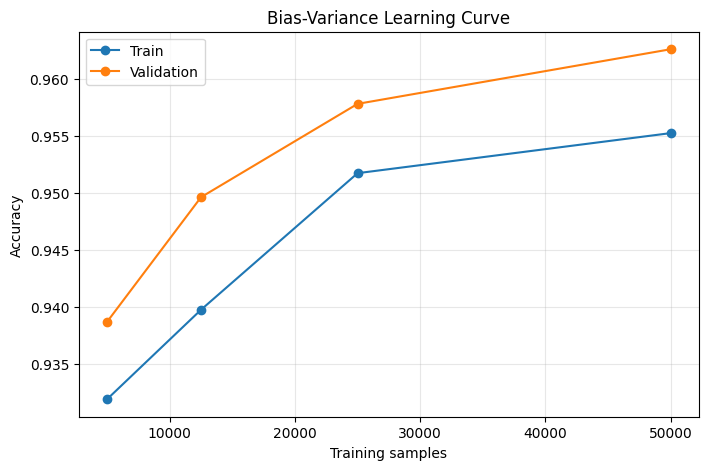

,train_size,train_score,val_score,gap
0,5000,0.93190,0.93870,-0.00680
1,12500,0.93976,0.94965,-0.00989
2,25000,0.95176,0.95785,-0.00609
3,50000,0.95528,0.96265,-0.00737


In [16]:
curve_mean = bias_variance_summary.groupby("train_size", as_index=False)[["train_score", "val_score", "gap"]].mean()

plt.figure(figsize=(8, 5))
plt.plot(curve_mean["train_size"], curve_mean["train_score"], marker="o", label="Train")
plt.plot(curve_mean["train_size"], curve_mean["val_score"], marker="o", label="Validation")
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Learning Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

curve_mean


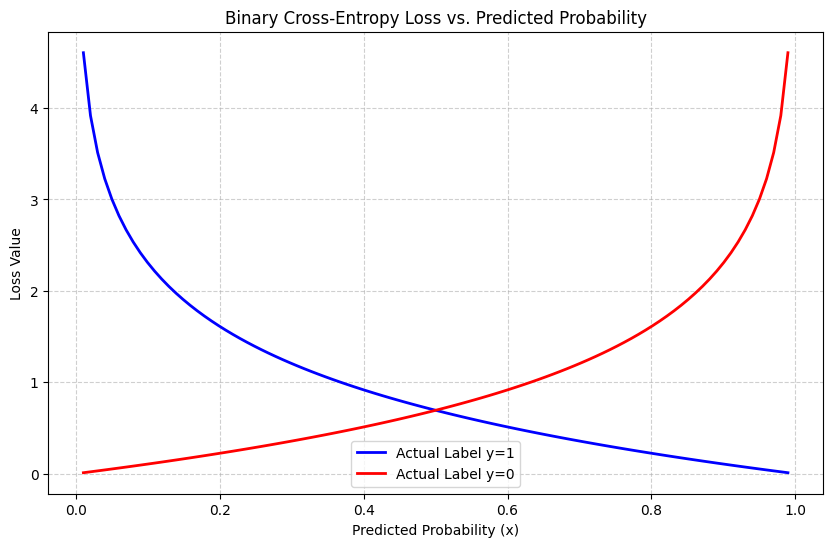

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.01, 0.99, 100)

loss_y1 = -np.log(x)           
loss_y0 = -np.log(1 - x)      

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(x, loss_y1, label='Actual Label y=1', color='blue', lw=2)
plt.plot(x, loss_y0, label='Actual Label y=0', color='red', lw=2)

plt.title('Binary Cross-Entropy Loss vs. Predicted Probability')
plt.xlabel('Predicted Probability (x)')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [18]:
import matplotlib.pyplot as plt

def visualize_weights(w, title="Weight Visualization"):
    # Remove bias term
    w_no_bias = w[:-1]  # (784,)

    # Reshape into 28x28 image
    img = w_no_bias.reshape(28, 28)

    # Plot
    plt.figure()
    plt.imshow(img, cmap='inferno')  # orange heatmap style
    plt.colorbar()
    plt.title(title)
    plt.axis('off')
    plt.show()
    
digit = 3
visualize_weights(weights, title=f"Digit {digit} Weights")

ValueError: cannot reshape array of size 144 into shape (28,28)